# Step 2: Image Preprocessing - China Fundus CIMT Dataset

This notebook performs image preprocessing for the China Fundus CIMT dataset before model training.

## Steps Performed:
1. Load metadata and images
2. Split patients into train (70%), validation (15%), test (15%)
3. Resize images from 512x512 to 224x224
4. Normalize pixel values to [0, 1]
5. Save preprocessed data as numpy arrays
6. Display sample images after preprocessing
7. Compute class weights for handling imbalance

In [13]:
# ============================================================
# BLOCK 1: IMPORTS
# ============================================================

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("STEP 2: IMAGE PREPROCESSING")
print("="*60)
print("All imports loaded successfully.")

STEP 2: IMAGE PREPROCESSING
All imports loaded successfully.


In [14]:
# ============================================================
# BLOCK 2: CONFIGURATION & PATHS
# ============================================================

# Paths
METADATA_PATH = '../data/retinal/China_Fundus_CIMT_Dataset/labels.json'
IMAGES_DIR = '../data/retinal/China_Fundus_CIMT_Dataset/images/'
OUTPUT_DIR = '../data/retinal/processed/'
PLOT_DIR = '../retinal_model/outputs/plots/'

# Create output directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# Image settings
TARGET_SIZE = (224, 224)  # Resize to 224x224 for CNN/ViT
TEST_SIZE = 0.15
VAL_SIZE = 0.15
RANDOM_STATE = 42

print(f"Metadata path: {METADATA_PATH}")
print(f"Images folder: {IMAGES_DIR}")
print(f"Output folder: {OUTPUT_DIR}")
print(f"Target image size: {TARGET_SIZE[0]}x{TARGET_SIZE[1]}")
print(f"Train/Validation/Test split: 70% / 15% / 15%")
print("="*60)

Metadata path: ../data/retinal/China_Fundus_CIMT_Dataset/labels.json
Images folder: ../data/retinal/China_Fundus_CIMT_Dataset/images/
Output folder: ../data/retinal/processed/
Target image size: 224x224
Train/Validation/Test split: 70% / 15% / 15%


In [15]:
# ============================================================
# BLOCK 3: LOAD METADATA
# ============================================================

print("\nLoading metadata...")

with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)

print(f"Total patients loaded: {len(metadata)}")

# Convert to list of dictionaries for easier processing
patient_data = []
for patient_id, info in metadata.items():
    patient_data.append({
        'patient_id': patient_id,
        'label': info['label'],
        'gender': info['gender'],
        'age': info['True_age'],
        'thickness': info['thickness'],
        'right_eye': info.get('right_eye'),
        'left_eye': info.get('left_eye')
    })

df = pd.DataFrame(patient_data)
print(f"DataFrame created with {len(df)} patients")

# Show class distribution
class_counts = df['label'].value_counts().sort_index()
print(f"\nClass Distribution:")
print(f"  Class 0 (Normal):    {class_counts.get(0, 0)} ({class_counts.get(0, 0)/len(df)*100:.2f}%)")
print(f"  Class 1 (Thickened): {class_counts.get(1, 0)} ({class_counts.get(1, 0)/len(df)*100:.2f}%)")
print("="*60)


Loading metadata...
Total patients loaded: 2903
DataFrame created with 2903 patients

Class Distribution:
  Class 0 (Normal):    849 (29.25%)
  Class 1 (Thickened): 2054 (70.75%)


In [16]:
# ============================================================
# BLOCK 4: FUNCTION TO LOAD AND PREPROCESS IMAGES
# ============================================================

def load_and_preprocess_image(image_path, target_size=(224, 224)):
    """
    Load an image, resize, and normalize.
    
    Args:
        image_path: Path to the image file
        target_size: Tuple (height, width) for resizing
    
    Returns:
        Normalized image array of shape (target_size[0], target_size[1], 3)
    """
    try:
        # Load image
        img = Image.open(image_path)
        
        # Convert to RGB (in case of grayscale or RGBA)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        # Resize
        img = img.resize(target_size, Image.Resampling.LANCZOS)
        
        # Convert to numpy array and normalize to [0, 1]
        img_array = np.array(img) / 255.0
        
        return img_array.astype(np.float32)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def load_patient_images(patient_row, images_dir, target_size=(224, 224)):
    """
    Load both left and right eye images for a patient.
    
    Args:
        patient_row: Row from DataFrame containing patient data
        images_dir: Directory containing images
        target_size: Target size for resizing
    
    Returns:
        Tuple of (right_image, left_image) as numpy arrays
    """
    right_eye = patient_row['right_eye']
    left_eye = patient_row['left_eye']
    
    right_path = os.path.join(images_dir, right_eye)
    left_path = os.path.join(images_dir, left_eye)
    
    right_img = load_and_preprocess_image(right_path, target_size)
    left_img = load_and_preprocess_image(left_path, target_size)
    
    return right_img, left_img

print("Image loading functions defined successfully.")

Image loading functions defined successfully.


In [17]:
# ============================================================
# BLOCK 5: LOAD ALL IMAGES
# ============================================================

print("\nLoading all images...")
print("This may take a few minutes.")

all_images = []
all_labels = []
all_patient_ids = []
failed_patients = []

for idx, row in df.iterrows():
    patient_id = row['patient_id']
    label = row['label']
    
    right_img, left_img = load_patient_images(row, IMAGES_DIR, TARGET_SIZE)
    
    if right_img is not None and left_img is not None:
        all_images.append(right_img)
        all_labels.append(label)
        all_patient_ids.append(f"{patient_id}_R")
        
        all_images.append(left_img)
        all_labels.append(label)
        all_patient_ids.append(f"{patient_id}_L")
    else:
        failed_patients.append(patient_id)

# Convert to numpy arrays
all_images = np.array(all_images, dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.int32)

print(f"\nTotal images loaded: {len(all_images)}")
print(f"Image shape: {all_images.shape}")
print(f"Failed patients: {len(failed_patients)}")
print("="*60)


Loading all images...
This may take a few minutes.

Total images loaded: 5806
Image shape: (5806, 224, 224, 3)
Failed patients: 0


In [18]:
# ============================================================
# BLOCK 6: TRAIN/VALIDATION/TEST SPLIT
# ============================================================

print("\nSplitting data into train/validation/test sets...")

# Get unique patient IDs for splitting
unique_patients = df['patient_id'].tolist()
patient_labels = df['label'].tolist()

# First split: 85% train, 15% temp (validation + test)
train_patients, temp_patients, train_labels, temp_labels = train_test_split(
    unique_patients, 
    patient_labels, 
    test_size=TEST_SIZE + VAL_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=patient_labels
)

# Second split: split temp into validation (50%) and test (50%)
val_ratio = VAL_SIZE / (TEST_SIZE + VAL_SIZE)
val_patients, test_patients, val_labels, test_labels = train_test_split(
    temp_patients, 
    temp_labels, 
    test_size=0.5, 
    random_state=RANDOM_STATE, 
    stratify=temp_labels
)

print(f"Train patients: {len(train_patients)}")
print(f"Validation patients: {len(val_patients)}")
print(f"Test patients: {len(test_patients)}")

# Create data masks for each split
train_mask = df['patient_id'].isin(train_patients)
val_mask = df['patient_id'].isin(val_patients)
test_mask = df['patient_id'].isin(test_patients)

# Get indices for each split
train_indices = np.where(train_mask)[0]
val_indices = np.where(val_mask)[0]
test_indices = np.where(test_mask)[0]

# Create image arrays for each split
train_images = []
train_labels_split = []
val_images = []
val_labels_split = []
test_images = []
test_labels_split = []

# Map patient index to image index (2 images per patient)
for idx in train_indices:
    # Right eye
    train_images.append(all_images[idx * 2])
    train_labels_split.append(all_labels[idx * 2])
    # Left eye
    train_images.append(all_images[idx * 2 + 1])
    train_labels_split.append(all_labels[idx * 2 + 1])

for idx in val_indices:
    val_images.append(all_images[idx * 2])
    val_labels_split.append(all_labels[idx * 2])
    val_images.append(all_images[idx * 2 + 1])
    val_labels_split.append(all_labels[idx * 2 + 1])

for idx in test_indices:
    test_images.append(all_images[idx * 2])
    test_labels_split.append(all_labels[idx * 2])
    test_images.append(all_images[idx * 2 + 1])
    test_labels_split.append(all_labels[idx * 2 + 1])

# Convert to numpy arrays
train_images = np.array(train_images, dtype=np.float32)
train_labels_split = np.array(train_labels_split, dtype=np.int32)
val_images = np.array(val_images, dtype=np.float32)
val_labels_split = np.array(val_labels_split, dtype=np.int32)
test_images = np.array(test_images, dtype=np.float32)
test_labels_split = np.array(test_labels_split, dtype=np.int32)

print(f"\nTrain images: {len(train_images)}")
print(f"Validation images: {len(val_images)}")
print(f"Test images: {len(test_images)}")
print("="*60)


Splitting data into train/validation/test sets...
Train patients: 2032
Validation patients: 435
Test patients: 436

Train images: 4064
Validation images: 870
Test images: 872


In [19]:
# ============================================================
# BLOCK 7: PRINT SPLIT STATISTICS
# ============================================================

print("\n" + "="*60)
print("DATA SPLIT STATISTICS")
print("="*60)

def print_split_stats(images, labels, name):
    total = len(images)
    class_0 = np.sum(labels == 0)
    class_1 = np.sum(labels == 1)
    print(f"\n{name}:")
    print(f"  Total images: {total}")
    print(f"  Class 0 (Normal): {class_0} ({class_0/total*100:.2f}%)")
    print(f"  Class 1 (Thickened): {class_1} ({class_1/total*100:.2f}%)")

print_split_stats(train_images, train_labels_split, "TRAINING SET")
print_split_stats(val_images, val_labels_split, "VALIDATION SET")
print_split_stats(test_images, test_labels_split, "TEST SET")

print("\n" + "="*60)


DATA SPLIT STATISTICS

TRAINING SET:
  Total images: 4064
  Class 0 (Normal): 1188 (29.23%)
  Class 1 (Thickened): 2876 (70.77%)

VALIDATION SET:
  Total images: 870
  Class 0 (Normal): 254 (29.20%)
  Class 1 (Thickened): 616 (70.80%)

TEST SET:
  Total images: 872
  Class 0 (Normal): 256 (29.36%)
  Class 1 (Thickened): 616 (70.64%)



In [20]:
# ============================================================
# BLOCK 8: DATA AUGMENTATION (OpenCV - No TensorFlow)
# ============================================================

print("\n" + "="*60)
print("DATA AUGMENTATION SETUP")
print("="*60)

import cv2
import numpy as np

def augment_image(image):
    """
    Apply augmentation to a single image using OpenCV.
    
    Args:
        image: numpy array of shape (H, W, 3) in [0, 1] range
    
    Returns:
        Augmented image as numpy array
    """
    # Convert to uint8 for OpenCV (0-255)
    img = (image * 255).astype(np.uint8)
    
    # Random horizontal flip (50% probability)
    if np.random.random() > 0.5:
        img = cv2.flip(img, 1)
    
    # Random rotation (±10 degrees)
    angle = np.random.uniform(-10, 10)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    
    # Random brightness adjustment (±10%)
    brightness = np.random.uniform(0.9, 1.1)
    img = np.clip(img * brightness, 0, 255).astype(np.uint8)
    
    # Random zoom (0.9 to 1.1)
    scale = np.random.uniform(0.9, 1.1)
    if scale != 1.0:
        h, w = img.shape[:2]
        new_h = int(h * scale)
        new_w = int(w * scale)
        img = cv2.resize(img, (new_w, new_h))
        img = cv2.resize(img, (w, h))
    
    # Convert back to [0, 1] range
    return img.astype(np.float32) / 255.0

print("Augmentation function created successfully (OpenCV):")
print("  - Horizontal flip: Yes (50% probability)")
print("  - Rotation range: ±10 degrees")
print("  - Brightness range: ±10%")
print("  - Zoom range: ±10%")
print("="*60)


DATA AUGMENTATION SETUP
Augmentation function created successfully (OpenCV):
  - Horizontal flip: Yes (50% probability)
  - Rotation range: ±10 degrees
  - Brightness range: ±10%
  - Zoom range: ±10%



DISPLAYING SAMPLE IMAGES


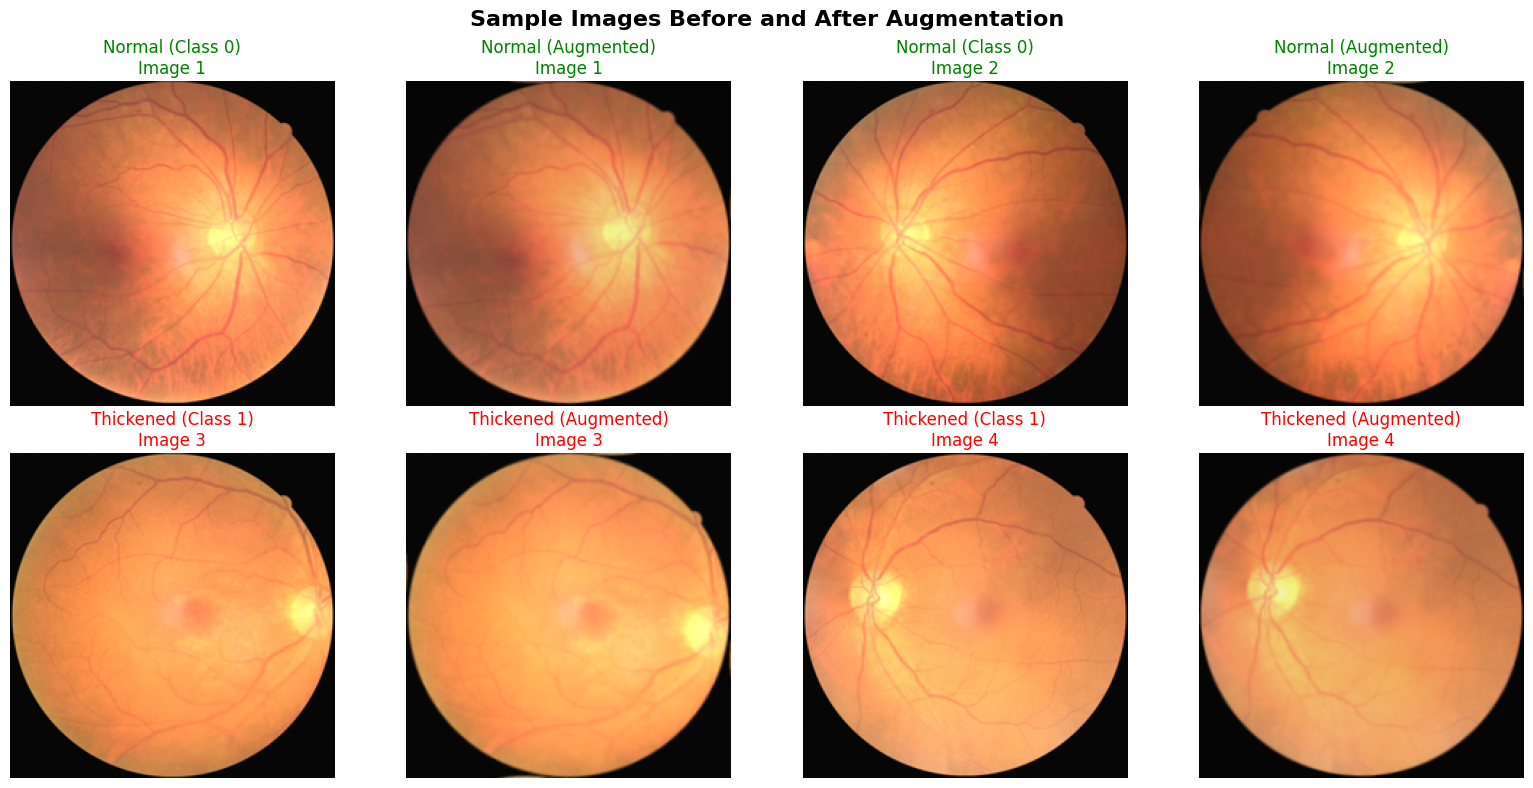

Sample images displayed and saved to outputs/plots/sample_augmentation.png


In [21]:
# ============================================================
# BLOCK 9: DISPLAY SAMPLE IMAGES
# ============================================================

import matplotlib.pyplot as plt

print("\n" + "="*60)
print("DISPLAYING SAMPLE IMAGES")
print("="*60)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Get indices of normal and thickened samples
normal_indices = np.where(train_labels_split == 0)[0]
thickened_indices = np.where(train_labels_split == 1)[0]

if len(normal_indices) >= 2 and len(thickened_indices) >= 2:
    # Normal samples (first 2)
    for i, idx in enumerate(normal_indices[:2]):
        # Original image
        axes[0, i*2].imshow(train_images[idx])
        axes[0, i*2].set_title(f"Normal (Class 0)\nImage {idx+1}", color='green')
        axes[0, i*2].axis('off')
        
        # Augmented version
        augmented = augment_image(train_images[idx])
        axes[0, i*2+1].imshow(np.clip(augmented, 0, 1))
        axes[0, i*2+1].set_title(f"Normal (Augmented)\nImage {idx+1}", color='green')
        axes[0, i*2+1].axis('off')
    
    # Thickened samples (first 2)
    for i, idx in enumerate(thickened_indices[:2]):
        # Original image
        axes[1, i*2].imshow(train_images[idx])
        axes[1, i*2].set_title(f"Thickened (Class 1)\nImage {idx+1}", color='red')
        axes[1, i*2].axis('off')
        
        # Augmented version
        augmented = augment_image(train_images[idx])
        axes[1, i*2+1].imshow(np.clip(augmented, 0, 1))
        axes[1, i*2+1].set_title(f"Thickened (Augmented)\nImage {idx+1}", color='red')
        axes[1, i*2+1].axis('off')

plt.suptitle('Sample Images Before and After Augmentation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'sample_augmentation.png'), dpi=300)
plt.show()
print("Sample images displayed and saved to outputs/plots/sample_augmentation.png")

In [22]:
# ============================================================
# BLOCK 10: COMPUTE CLASS WEIGHTS FOR IMBALANCE HANDLING
# ============================================================

print("\n" + "="*60)
print("COMPUTING CLASS WEIGHTS")
print("="*60)

from sklearn.utils.class_weight import compute_class_weight

# Compute class weights for training data
classes = np.unique(train_labels_split)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_labels_split
)

class_weight_dict = {cls: weight for cls, weight in zip(classes, class_weights)}

print(f"Class weights computed:")
print(f"  Class 0 (Normal):    {class_weight_dict.get(0, 0):.4f}")
print(f"  Class 1 (Thickened): {class_weight_dict.get(1, 0):.4f}")

# Save class weights
np.save(os.path.join(OUTPUT_DIR, 'class_weights.npy'), class_weights)
print(f"Class weights saved to: {OUTPUT_DIR}class_weights.npy")
print("="*60)


COMPUTING CLASS WEIGHTS
Class weights computed:
  Class 0 (Normal):    1.7104
  Class 1 (Thickened): 0.7065
Class weights saved to: ../data/retinal/processed/class_weights.npy


In [23]:
# ============================================================
# BLOCK 11: SAVE PREPROCESSED DATA
# ============================================================

print("\n" + "="*60)
print("SAVING PREPROCESSED DATA")
print("="*60)

# Save training data
np.save(os.path.join(OUTPUT_DIR, 'train_images.npy'), train_images)
np.save(os.path.join(OUTPUT_DIR, 'train_labels.npy'), train_labels_split)
print(f"Train images saved: {train_images.shape} -> {OUTPUT_DIR}train_images.npy")
print(f"Train labels saved: {train_labels_split.shape} -> {OUTPUT_DIR}train_labels.npy")

# Save validation data
np.save(os.path.join(OUTPUT_DIR, 'val_images.npy'), val_images)
np.save(os.path.join(OUTPUT_DIR, 'val_labels.npy'), val_labels_split)
print(f"Validation images saved: {val_images.shape} -> {OUTPUT_DIR}val_images.npy")
print(f"Validation labels saved: {val_labels_split.shape} -> {OUTPUT_DIR}val_labels.npy")

# Save test data
np.save(os.path.join(OUTPUT_DIR, 'test_images.npy'), test_images)
np.save(os.path.join(OUTPUT_DIR, 'test_labels.npy'), test_labels_split)
print(f"Test images saved: {test_images.shape} -> {OUTPUT_DIR}test_images.npy")
print(f"Test labels saved: {test_labels_split.shape} -> {OUTPUT_DIR}test_labels.npy")

print("\n" + "="*60)
print("PREPROCESSING COMPLETE")
print("="*60)
print(f"\nData saved to: {OUTPUT_DIR}")
print("\nFiles created:")
print("  - train_images.npy")
print("  - train_labels.npy")
print("  - val_images.npy")
print("  - val_labels.npy")
print("  - test_images.npy")
print("  - test_labels.npy")
print("  - class_weights.npy")


SAVING PREPROCESSED DATA
Train images saved: (4064, 224, 224, 3) -> ../data/retinal/processed/train_images.npy
Train labels saved: (4064,) -> ../data/retinal/processed/train_labels.npy
Validation images saved: (870, 224, 224, 3) -> ../data/retinal/processed/val_images.npy
Validation labels saved: (870,) -> ../data/retinal/processed/val_labels.npy
Test images saved: (872, 224, 224, 3) -> ../data/retinal/processed/test_images.npy
Test labels saved: (872,) -> ../data/retinal/processed/test_labels.npy

PREPROCESSING COMPLETE

Data saved to: ../data/retinal/processed/

Files created:
  - train_images.npy
  - train_labels.npy
  - val_images.npy
  - val_labels.npy
  - test_images.npy
  - test_labels.npy
  - class_weights.npy


In [24]:
# ============================================================
# BLOCK 12: FINAL SUMMARY
# ============================================================

print("\n" + "="*60)
print("PREPROCESSING SUMMARY")
print("="*60)

print(f"\nDataset Information:")
print(f"  Total patients: {len(df)}")
print(f"  Total images: {len(all_images)}")
print(f"  Image size after preprocessing: {TARGET_SIZE[0]}x{TARGET_SIZE[1]}x3")
print(f"  Normalization: [0, 1]")
print(f"  Data type: float32")

print(f"\nSplit Summary:")
print(f"  Training:   {len(train_images)} images ({len(train_images)/len(all_images)*100:.1f}%)")
print(f"  Validation: {len(val_images)} images ({len(val_images)/len(all_images)*100:.1f}%)")
print(f"  Test:       {len(test_images)} images ({len(test_images)/len(all_images)*100:.1f}%)")

print(f"\nClass Distribution in Training:")
print(f"  Class 0 (Normal):    {np.sum(train_labels_split == 0)} ({np.sum(train_labels_split == 0)/len(train_labels_split)*100:.2f}%)")
print(f"  Class 1 (Thickened): {np.sum(train_labels_split == 1)} ({np.sum(train_labels_split == 1)/len(train_labels_split)*100:.2f}%)")

print(f"\nClass Weights (for imbalanced loss):")
print(f"  Class 0 (Normal):    {class_weight_dict.get(0, 0):.4f}")
print(f"  Class 1 (Thickened): {class_weight_dict.get(1, 0):.4f}")

print(f"\nAugmentation:")
print(f"  Applied only to training data")
print(f"  Horizontal flip: True")
print(f"  Rotation: ±10°")
print(f"  Brightness: ±10%")
print(f"  Zoom: ±10%")

print("\n" + "="*60)
print("STEP 2 COMPLETE")
print("="*60)


PREPROCESSING SUMMARY

Dataset Information:
  Total patients: 2903
  Total images: 5806
  Image size after preprocessing: 224x224x3
  Normalization: [0, 1]
  Data type: float32

Split Summary:
  Training:   4064 images (70.0%)
  Validation: 870 images (15.0%)
  Test:       872 images (15.0%)

Class Distribution in Training:
  Class 0 (Normal):    1188 (29.23%)
  Class 1 (Thickened): 2876 (70.77%)

Class Weights (for imbalanced loss):
  Class 0 (Normal):    1.7104
  Class 1 (Thickened): 0.7065

Augmentation:
  Applied only to training data
  Horizontal flip: True
  Rotation: ±10°
  Brightness: ±10%
  Zoom: ±10%

STEP 2 COMPLETE
